# Client Mgas/s Performance vs the 100 Mgas/s Anchor — glamsterdam-devnet-8

#### Maria Silva, September 2026

We compare per-test median throughput from benchmarkoor against the **100 Mgas/s** anchor and a less demanding **50 Mgas/s** threshold, for the stateful and compute full suites. A miss means the **median across runs** is below the threshold; it neither counts individual slow runs nor proves that every run passes.

| Suite hash | Suite name | Registry tests |
| --- | --- | --- |
| `7eec9e8fcd40b131` | `jochemnet-glamsterdam-devnet-8-stateful-full` | 692 |
| `3271e4695a46a243` | `jochemnet-glamsterdam-devnet-8-compute-full` | 2302 |

**Units.** `test_mgas_s = 1_000 * test_gas_used / test_time_ns`, validated against the API values. Rates are comparable to the anchor at the measured workload size. Projecting them to a different block size would assume constant throughput, which these measurements do not establish.

**Scope.** Runs must start in the half-open UTC interval `[AS_OF - LOOKBACK_DAYS, AS_OF)` — here the four days ending 2026-09-14. For `besu`, only the `besu-bal-full-aot` instance is included. Stateful overhead baselines are excluded.

**Questions:**
1. How many test medians fall below 100 and 50 Mgas/s?
2. How does throughput vary across tests and clients?
3. Which test functions account for the misses?
4. Which tests targeting 200M gas have median execution time above six seconds?

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

In [2]:
sns.set_theme(
    style="whitegrid", palette="Set2", rc={"figure.dpi": 150, "axes.titlesize": 15}
)
np.random.seed(0)  # Reproducible jitter in strip plots.

# Support execution from either the repository root or notebooks/.
repo_dir = Path.cwd()
if not (repo_dir / "data").is_dir():
    repo_dir = repo_dir.parent
if not (repo_dir / "data").is_dir():
    raise FileNotFoundError("Run this notebook from the repository root or notebooks/.")

Cached analysis is offline: credentials and an HTTP session are needed only when `USE_CACHE = False`. Both cache files must exist when using the cache. The window filter is reapplied locally, which also protects against older caches that included later runs.

In [3]:
BENCHMARKOOR_BASE_URL = (
    "https://benchmarkoor-api.core.ethpandaops.io/api/v1/index/query"
)
SUITES = {"7eec9e8fcd40b131": "stateful", "3271e4695a46a243": "compute"}
SUITE_ORDER = list(SUITES.values())
REGISTRY_TESTS = pd.Series({"stateful": 692, "compute": 2302}, name="registry_tests")
CLIENT_ORDER = ["besu", "erigon", "ethrex", "geth", "nethermind", "reth"]

ANCHOR_MGAS_S = 100
SOFT_MGAS_S = 50
TIME_BUDGET_S = 6
AS_OF = pd.Timestamp("2026-09-14", tz="UTC")
LOOKBACK_DAYS = 4
WINDOW_START = AS_OF - pd.Timedelta(days=LOOKBACK_DAYS)
BESU_INSTANCE = "besu-bal-full-aot"
PAGE_SIZE = 10_000
CACHE_PATH = repo_dir / "data" / f"mgas_s_devnet8_two_suites_{AS_OF:%Y-%m-%d}.parquet"
RUNS_CACHE_PATH = (
    repo_dir / "data" / f"mgas_s_devnet8_two_suites_runs_{AS_OF:%Y-%m-%d}.parquet"
)

print(f"Run starts: [{WINDOW_START}, {AS_OF})")

Run starts: [2026-09-10 00:00:00+00:00, 2026-09-14 00:00:00+00:00)


## 1. Data collection and validation

We fetch runs in the configured UTC window, then fetch their test results one run at a time to avoid the API's disk I/O error on large sorted queries. Both endpoints use ordered pagination, retries, and timeouts. The same time bounds are rechecked locally. Preserve both cache files to reproduce this snapshot.

In [4]:
def fetch_rows(
    session, endpoint, *, suite_hash, columns, time_column, order, run_id=None
):
    """Fetch a suite's rows in the configured half-open window, in stable order."""
    params = {
        "select": columns,
        "suite_hash": f"eq.{suite_hash}",
        # requests encodes the list as repeated filters on the same column.
        time_column: [
            f"gte.{int(WINDOW_START.timestamp())}",
            f"lt.{int(AS_OF.timestamp())}",
        ],
        "order": order,
        "limit": PAGE_SIZE,
    }
    if run_id is not None:
        params["run_id"] = f"eq.{run_id}"
        # The run inventory already enforces the window; recheck it locally below.
        params.pop(time_column)
    if endpoint == "test_stats":
        params["test_time_ns"] = "gt.0"
    rows = []
    while True:
        response = session.get(
            f"{BENCHMARKOOR_BASE_URL}/{endpoint}",
            params={**params, "offset": len(rows)},
            timeout=(10, 120),
        )
        response.raise_for_status()
        page = response.json()["data"]
        if not page:
            return pd.DataFrame(rows, columns=columns.split(","))
        rows.extend(page)
        # Continue until empty, even if the server caps pages below PAGE_SIZE.

In [5]:
USE_CACHE = True

if USE_CACHE:
    raw_df = pd.read_parquet(CACHE_PATH)
    runs_df = pd.read_parquet(RUNS_CACHE_PATH)
    print(f"Loaded {CACHE_PATH.relative_to(repo_dir)} and {RUNS_CACHE_PATH.name}")
else:
    with (repo_dir / "secrets.json").open() as file:
        bearer_token = json.load(file)["benchmarkoor_bearer_token"]
    frames, run_frames = [], []
    with requests.Session() as session:
        retries = Retry(
            total=5, backoff_factor=2, status_forcelist=[429, 502, 503, 504, 524]
        )
        session.mount("https://", HTTPAdapter(max_retries=retries))
        session.headers["Authorization"] = f"Bearer {bearer_token}"
        for suite_hash, suite in SUITES.items():
            run_frames.append(
                fetch_rows(
                    session,
                    "runs",
                    suite_hash=suite_hash,
                    columns="run_id,client,image,instance_id,timestamp,status,tests_total,tests_passed,tests_failed",
                    time_column="timestamp",
                    order="run_id.asc,client.asc",
                ).assign(suite=suite)
            )
            print(f"Fetching {suite}: {len(run_frames[-1]):,} runs", flush=True)
            for run_id in run_frames[-1]["run_id"]:
                frames.append(
                    fetch_rows(
                        session,
                        "test_stats",
                        suite_hash=suite_hash,
                        run_id=run_id,
                        columns="run_id,client,test_name,test_gas_used,test_time_ns,test_mgas_s,run_start",
                        time_column="run_start",
                        order="run_id.asc,client.asc,test_name.asc",
                    ).assign(suite=suite)
                )
    raw_df = pd.concat(frames, ignore_index=True)
    runs_df = pd.concat(run_frames, ignore_index=True)
    runs_df["run_timestamp"] = pd.to_datetime(
        runs_df.pop("timestamp"), unit="s", utc=True
    )
    raw_df.to_parquet(CACHE_PATH, index=False)
    runs_df.to_parquet(RUNS_CACHE_PATH, index=False)

# Normalize legacy naive timestamps as UTC, and enforce bounds even for caches.
runs_df["run_timestamp"] = pd.to_datetime(runs_df["run_timestamp"], utc=True)
run_starts = pd.to_datetime(raw_df["run_start"], unit="s", utc=True)
measurement_count = len(raw_df)
run_count = len(runs_df)
raw_df = raw_df[run_starts.between(WINDOW_START, AS_OF, inclusive="left")].copy()
runs_df = runs_df[
    runs_df["run_timestamp"].between(WINDOW_START, AS_OF, inclusive="left")
].copy()
print(
    f"Outside window: {measurement_count - len(raw_df):,} measurements, {run_count - len(runs_df)} runs"
)

RUN_KEY = ["suite", "client", "run_id"]
TEST_KEY = ["suite", "client", "test_name"]
assert not runs_df.duplicated(RUN_KEY).any(), "Duplicate run metadata"
assert not raw_df.duplicated(
    RUN_KEY + ["test_name"]
).any(), "Duplicate run/test measurements"
assert (
    raw_df[RUN_KEY + ["test_name"]].notna().all().all()
), "Missing measurement identity"
assert (raw_df[["test_time_ns", "test_gas_used", "test_mgas_s"]] > 0).all().all()
np.testing.assert_allclose(
    raw_df["test_mgas_s"],
    raw_df["test_gas_used"] * 1_000 / raw_df["test_time_ns"],
    rtol=1e-9,
)
print(f"{len(raw_df):,} measurements in the configured window")

Loaded data/mgas_s_devnet8_two_suites_2026-09-14.parquet and mgas_s_devnet8_two_suites_runs_2026-09-14.parquet
Outside window: 0 measurements, 0 runs


1,907,252 measurements in the configured window


### Run inventory and the Besu instance filter

This inventory uses only runs inside the configured window. We select Besu's AOT instance below; the other clients retain all listed images and statuses.

In [6]:
display(
    runs_df.groupby(["suite", "client", "instance_id", "image", "status"])
    .agg(
        n_runs=("run_id", "size"),
        tests_total=("tests_total", "max"),
        tests_failed=("tests_failed", "sum"),
        first_run=("run_timestamp", "min"),
        last_run=("run_timestamp", "max"),
    )
    .reindex(SUITE_ORDER, level="suite")
)

n_runs  \
suite    client     instance_id         image                                             status              
stateful besu       besu-bal-full-aot   ethpandaops/besu:glamsterdam-devnet-8-aot-0d7d0f5 completed      18   
         erigon     erigon-bal-full     ethpandaops/erigon:main                           completed      14   
         ethrex     ethrex-bal-full     ethpandaops/ethrex:main                           completed      16   
         geth       geth-bal-full       ethpandaops/geth:master                           completed     428   
         nethermind nethermind-bal-full ethpandaops/nethermind:master                     completed      16   
         reth       reth-bal-full       ethpandaops/reth:glamsterdam-devnet-8             completed      14   
compute  besu       besu-bal-full-aot   ethpandaops/besu:glamsterdam-devnet-8-aot-0d7d0f5 completed     111   
         erigon     erigon-bal-full     ethpandaops/erigon:main                           completed      29   
         ethrex     ethrex-bal-full     ethpandaops/ethrex:main                           completed      17   
         geth       geth-bal-full       ethpandaops/geth:master                           completed     202   
         nethermind nethermind-bal-full ethpandaops/nethermind:master                     completed     216   
         reth       reth-bal-full       ethpandaops/reth:glamsterdam-devnet-8             completed     102   

                                                                                                     tests_total  \
suite    client     instance_id         image                                             status                   
stateful besu       besu-bal-full-aot   ethpandaops/besu:glamsterdam-devnet-8-aot-0d7d0f5 completed          692   
         erigon     erigon-bal-full     ethpandaops/erigon:main                           completed          692   
         ethrex     ethrex-bal-full     ethpandaops/ethrex:main                           completed          692   
         geth       geth-bal-full       ethpandaops/geth:master                           completed          692   
         nethermind nethermind-bal-full ethpandaops/nethermind:master                     completed          692   
         reth       reth-bal-full       ethpandaops/reth:glamsterdam-devnet-8             completed          692   
compute  besu       besu-bal-full-aot   ethpandaops/besu:glamsterdam-devnet-8-aot-0d7d0f5 completed         2302   
         erigon     erigon-bal-full     ethpandaops/erigon:main                           completed         2302   
         ethrex     ethrex-bal-full     ethpandaops/ethrex:main                           completed         2302   
         geth       geth-bal-full       ethpandaops/geth:master                           completed         2302   
         nethermind nethermind-bal-full ethpandaops/nethermind:master                     completed         2302   
         reth       reth-bal-full       ethpandaops/reth:glamsterdam-devnet-8             completed         2302   

                                                                                                     tests_failed  \
suite    client     instance_id         image                                             status                    
stateful besu       besu-bal-full-aot   ethpandaops/besu:glamsterdam-devnet-8-aot-0d7d0f5 completed             0   
         erigon     erigon-bal-full     ethpandaops/erigon:main                           completed             0   
         ethrex     ethrex-bal-full     ethpandaops/ethrex:main                           completed             0   
         geth       geth-bal-full       ethpandaops/geth:master                           completed             0   
         nethermind nethermind-bal-full ethpandaops/nethermind:master                     completed             0   
         reth       reth-bal-full       ethpandaops/reth:glamsterdam-devnet-8             completed   

In [7]:
kept_runs_df = runs_df[
    (runs_df["client"] != "besu") | (runs_df["instance_id"] == BESU_INSTANCE)
].copy()
print(f"Dropped {len(runs_df) - len(kept_runs_df)} Besu runs from other instances")

# Detect missing metadata before deliberately excluding out-of-scope instances.
assert (
    pd.MultiIndex.from_frame(raw_df[RUN_KEY])
    .isin(pd.MultiIndex.from_frame(runs_df[RUN_KEY]))
    .all()
), "Measurements without matching run metadata"
df = raw_df.merge(
    kept_runs_df[RUN_KEY + ["instance_id", "image", "status"]],
    on=RUN_KEY,
    how="inner",
    validate="many_to_one",
)
print(f"{len(df):,} measurements kept after instance filtering")

Dropped 0 Besu runs from other instances


1,907,252 measurements kept after instance filtering


**Every run in this window completed cleanly.** All 1,183 runs report `completed` status with zero failed tests, and each client ran a single image per suite — so there are no partial runs or mixed builds to discount here.

Two caveats remain. Repetition counts differ by a factor of 30 across clients (14 to 428 runs per test), so the medians are not equally precise. And results describe this particular build and hardware mix; they do not isolate client implementation differences.

In [8]:
# Parse each distinct name once; metadata is not part of the aggregation key.
test_metadata = df[["suite", "test_name"]].drop_duplicates().copy()
parts = test_metadata["test_name"].str.extract(
    r"^(?P<test_file>.+)::(?P<test_func>[^\[]+)\[(?P<test_params>.*)\]$"
)
assert parts.notna().all().all(), "Unexpected test-name format"
test_metadata = pd.concat([test_metadata, parts], axis=1)
test_metadata["target_gas_m"] = pd.to_numeric(
    test_metadata["test_params"].str.extract(r"gas-value_(\d+)M")[0],
    errors="raise",
)
assert test_metadata["target_gas_m"].notna().all(), "Missing target gas in test name"
test_metadata["is_baseline"] = test_metadata["test_params"].str.contains(
    "overhead_baseline_True",
    regex=False,
)

baseline_counts = (
    test_metadata.groupby("suite")["is_baseline"]
    .sum()
    .reindex(SUITE_ORDER, fill_value=0)
)
suite_coverage = REGISTRY_TESTS.to_frame()
suite_coverage["observed_raw_tests"] = test_metadata.groupby("suite")[
    "test_name"
].nunique()
suite_coverage["excluded_baselines"] = baseline_counts
suite_coverage["expected_analysis_tests"] = REGISTRY_TESTS - baseline_counts
suite_coverage["unobserved_registry_tests"] = (
    REGISTRY_TESTS - suite_coverage["observed_raw_tests"]
)
display(suite_coverage)

,registry_tests,observed_raw_tests,excluded_baselines,expected_analysis_tests,unobserved_registry_tests
stateful,692,692,160,532,0
compute,2302,2300,0,2302,2


The `overhead_baseline_True` variants are calibration workloads rather than the intended full workloads, so we exclude them. `expected_analysis_tests` subtracts them from the registry total.

Two compute tests are missing from the measurements. Run metadata reports 2,302 of 2,302 tests passing on every run, so these are passes without a positive recorded timing — the query requires `test_time_ns > 0` — rather than tests that never ran.

In [9]:
by_test_df = (
    df.groupby(TEST_KEY, as_index=False)
    .agg(
        median_mgas_s=("test_mgas_s", "median"),
        min_mgas_s=("test_mgas_s", "min"),
        median_time_ns=("test_time_ns", "median"),
        min_gas_used=("test_gas_used", "min"),
        max_gas_used=("test_gas_used", "max"),
        n_runs=("run_id", "nunique"),
    )
    .merge(test_metadata, on=["suite", "test_name"], validate="many_to_one")
    .loc[lambda d: ~d["is_baseline"]]
    .copy()
)
by_test_df["median_time_s"] = by_test_df.pop("median_time_ns") / 1e9
by_test_df["below_anchor"] = by_test_df["median_mgas_s"] < ANCHOR_MGAS_S
by_test_df["below_soft"] = by_test_df["median_mgas_s"] < SOFT_MGAS_S
print(f"{len(by_test_df):,} observed (suite, client, test) pairs assessed")

16,992 observed (suite, client, test) pairs assessed


In [10]:
# Include every expected client/suite, even if it has no measurements.
comparison_index = pd.MultiIndex.from_product(
    [SUITE_ORDER, CLIENT_ORDER], names=["suite", "client"]
)
coverage = (
    by_test_df.groupby(["suite", "client"])
    .agg(
        observed_tests=("test_name", "size"),
        min_runs_per_test=("n_runs", "min"),
        median_runs_per_test=("n_runs", "median"),
        max_runs_per_test=("n_runs", "max"),
    )
    .reindex(comparison_index)
)
coverage["observed_tests"] = coverage["observed_tests"].fillna(0).astype(int)
coverage["expected_tests"] = coverage.index.get_level_values("suite").map(
    suite_coverage["expected_analysis_tests"]
)
coverage["unobserved_tests"] = coverage["expected_tests"] - coverage["observed_tests"]
assert (
    coverage["unobserved_tests"] >= 0
).all(), "Observed tests exceed registry expectation"
display(coverage)

observed_tests  min_runs_per_test  median_runs_per_test  \
suite    client                                                                
stateful besu                   532                 18                  18.0   
         erigon                 532                 14                  14.0   
         ethrex                 532                 16                  16.0   
         geth                   532                428                 428.0   
         nethermind             532                 16                  16.0   
         reth                   532                 14                  14.0   
compute  besu                  2300                111                 111.0   
         erigon                2300                 29                  29.0   
         ethrex                2300                 17                  17.0   
         geth                  2300                202                 202.0   
         nethermind            2300                216                 216.0   
         reth                  2300                102                 102.0   

                     max_runs_per_test  expected_tests  unobserved_tests  
suite    client                                                           
stateful besu                       18             532                 0  
         erigon                     14             532                 0  
         ethrex                     16             532                 0  
         geth                      428             532                 0  
         nethermind                 16             532                 0  
         reth                       14             532                 0  
compute  besu                      111            2302                 2  
         erigon                     29            2302                 2  
         ethrex                     17            2302                 2  
         geth                      202            2302                 2  
         nethermind                216            2302                 2  
         reth                      102            2302                 2

## 2. Counts below the thresholds, per client and per suite

Each observed test contributes equally after taking its median Mgas/s across runs. Percentages use **observed tests** as the denominator. These are descriptive statistics for this suite and run mix, not a workload-frequency-weighted estimate of production throughput or a guarantee about the slowest individual execution.

In [11]:
threshold_summary = (
    by_test_df.groupby(["suite", "client"])
    .agg(
        n_below_anchor=("below_anchor", "sum"),
        n_below_soft=("below_soft", "sum"),
        slowest_mgas_s=("median_mgas_s", "min"),
        median_mgas_s=("median_mgas_s", "median"),
    )
    .reindex(comparison_index)
    .join(coverage)
)
threshold_summary["pct_below_anchor"] = (
    100 * threshold_summary["n_below_anchor"] / threshold_summary["observed_tests"]
)
threshold_summary["pct_below_soft"] = (
    100 * threshold_summary["n_below_soft"] / threshold_summary["observed_tests"]
)
threshold_summary = threshold_summary.reset_index()
display(threshold_summary.set_index(["suite", "client"]).round(1))

n_below_anchor  n_below_soft  slowest_mgas_s  \
suite    client                                                     
stateful besu                   118             0            61.2   
         erigon                  35             0            53.8   
         ethrex                  16             0            72.1   
         geth                    40             0            63.5   
         nethermind              24             0            74.9   
         reth                    32             0            63.1   
compute  besu                     0             0           171.5   
         erigon                   0             0           197.6   
         ethrex                   1             0            96.7   
         geth                     0             0           129.3   
         nethermind               0             0           230.3   
         reth                     0             0           232.3   

                     median_mgas_s  observed_tests  min_runs_per_test  \
suite    client                                                         
stateful besu                149.1             532                 18   
         erigon              588.8             532                 14   
         ethrex              983.6             532                 16   
         geth                389.7             532                428   
         nethermind          610.9             532                 16   
         reth                601.6             532                 14   
compute  besu                808.5            2300                111   
         erigon             2261.3            2300                 29   
         ethrex             3671.3            2300                 17   
         geth               2324.9            2300                202   
         nethermind         4773.5            2300                216   
         reth               4216.5            2300                102   

                     median_runs_per_test  max_runs_per_test  expected_tests  \
suite    client                                                                
stateful besu                        18.0                 18             532   
         erigon                      14.0                 14             532   
         ethrex                      16.0                 16             532   
         geth                       428.0                428             532   
         nethermind                  16.0                 16             532   
         reth                        14.0                 14             532   
compute  besu                       111.0                111            2302   
         erigon                      29.0                 29            2302   
         ethrex                      17.0                 17            2302   
         geth                       202.0                202            2302   
         nethermind                 216.0                216            2302   
         reth                       102.0                102            2302   

                     unobserved_tests  pct_below_anchor  pct_below_soft  
suite    client                                                          
stateful besu                       0              22.2             0.0  
         erigon                     0               6.6             0.0  
         ethrex                     0               3.0             0.0  
         geth                       0               7.5             0.0  
         nethermind                 0               4.5             0.0  
         reth                       0               6.0             0.0  
compute  besu                       2               0.0             0.0  
         erigon                     2               0.0             0.0  
         ethrex                     2               0.0             0.0  
         geth                       2               0.0             0.0  
         nethermind   

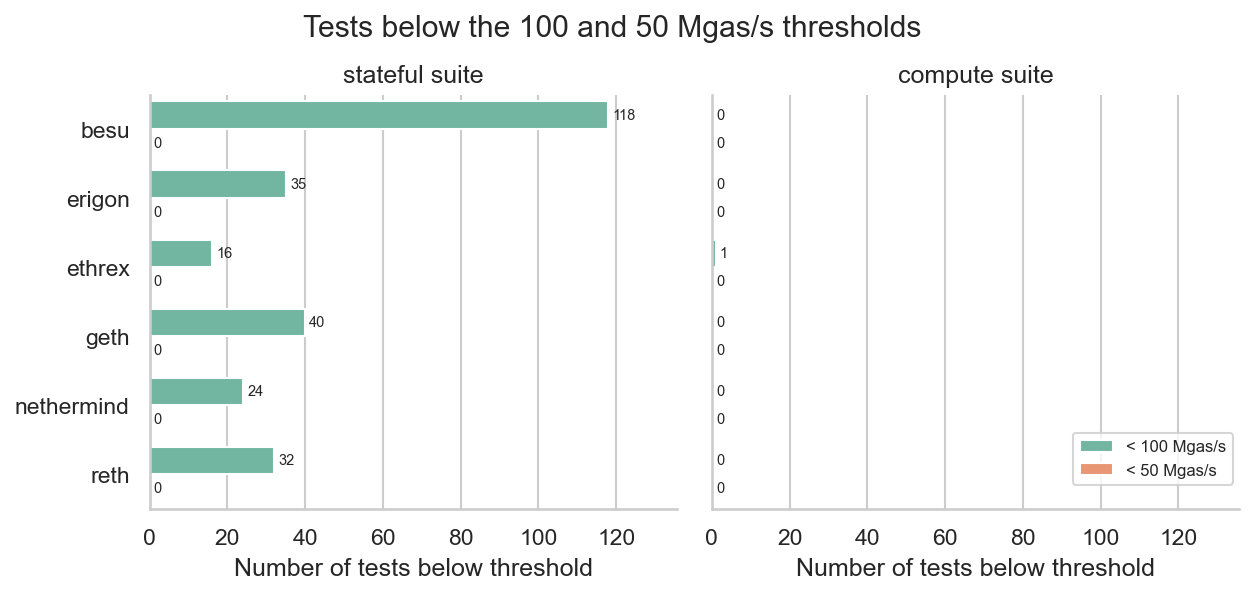

In [12]:
count_df = threshold_summary.melt(
    id_vars=["suite", "client"],
    value_vars=["n_below_anchor", "n_below_soft"],
    var_name="threshold",
    value_name="n_below",
).replace(
    {
        "n_below_anchor": f"< {ANCHOR_MGAS_S} Mgas/s",
        "n_below_soft": f"< {SOFT_MGAS_S} Mgas/s",
    }
)

g = sns.catplot(
    data=count_df,
    y="client",
    x="n_below",
    hue="threshold",
    order=CLIENT_ORDER,
    col="suite",
    col_order=SUITE_ORDER,
    kind="bar",
    height=3.8,
    aspect=1.15,
    legend_out=False,
)
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt="%.0f", padding=2, fontsize=7)
    ax.margins(x=0.15)
g.set_titles("{col_name} suite")
g.set_xlabels("Number of tests below threshold")
g.set_ylabels("")
sns.move_legend(g, "lower right", title="", fontsize=8, bbox_to_anchor=(0.98, 0.20))
g.figure.suptitle(
    f"Tests below the {ANCHOR_MGAS_S} and {SOFT_MGAS_S} Mgas/s thresholds", y=1.04
)
plt.show()

**The misses are stateful, and they concentrate in Besu.** Every client has stateful medians below the anchor, ranging from 16 tests for ethrex to 118 for besu (22% of its 532 stateful tests). The compute suite has a single miss across all six clients.

**Nothing falls below 50 Mgas/s** in either suite — not even the minimum across runs for any test. Near-threshold counts can still shift with the time window or build mix.

## 3. Per-test throughput distribution by client

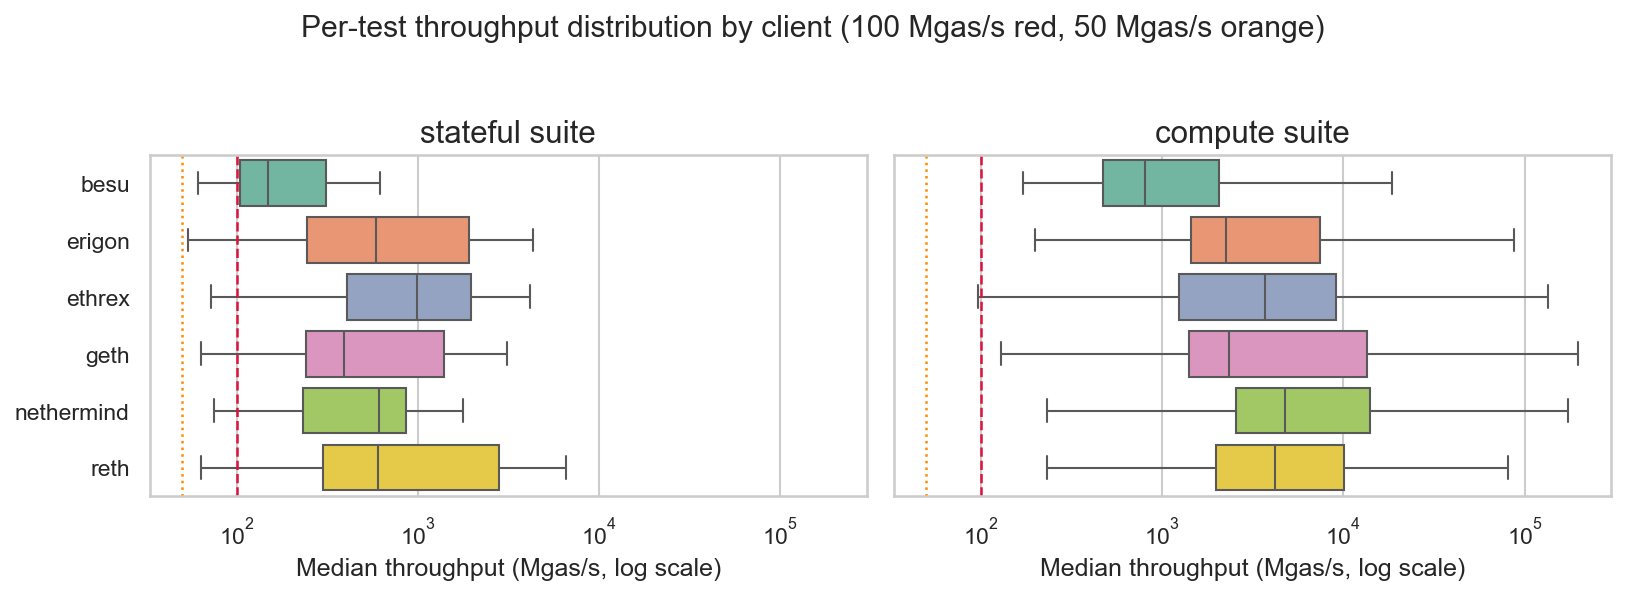

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharex=True)
for ax, suite in zip(axes, SUITE_ORDER):
    sns.boxplot(
        data=by_test_df[by_test_df["suite"] == suite],
        y="client",
        x="median_mgas_s",
        hue="client",
        hue_order=CLIENT_ORDER,
        order=CLIENT_ORDER,
        legend=False,
        showfliers=False,
        ax=ax,
    )
    ax.axvline(ANCHOR_MGAS_S, color="crimson", linestyle="--", linewidth=1.2)
    ax.axvline(SOFT_MGAS_S, color="darkorange", linestyle=":", linewidth=1.2)
    ax.set_xscale("log")
    ax.set_xlabel("Median throughput (Mgas/s, log scale)")
    ax.set_ylabel("")
    ax.set_title(f"{suite} suite")
axes[1].set_yticklabels([])
fig.suptitle(
    f"Per-test throughput distribution by client "
    f"({ANCHOR_MGAS_S} Mgas/s red, {SOFT_MGAS_S} Mgas/s orange)",
    y=1.04,
)
plt.tight_layout()
plt.show()

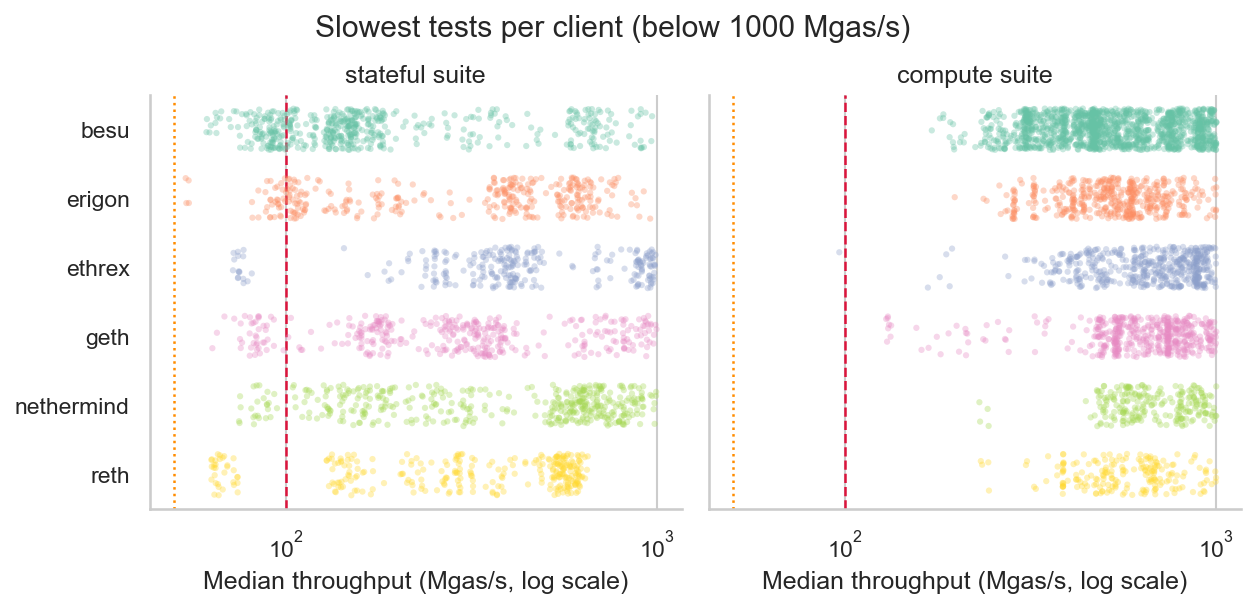

In [14]:
plot_df = by_test_df[by_test_df["median_mgas_s"] < 1000]

g = sns.catplot(
    data=plot_df,
    y="client",
    x="median_mgas_s",
    hue="client",
    hue_order=CLIENT_ORDER,
    order=CLIENT_ORDER,
    col="suite",
    col_order=SUITE_ORDER,
    kind="strip",
    alpha=0.35,
    size=3,
    jitter=0.3,
    legend=False,
    height=3.8,
    aspect=1.15,
)
for ax in g.axes.flat:
    ax.axvline(ANCHOR_MGAS_S, color="crimson", linestyle="--", linewidth=1.2)
    ax.axvline(SOFT_MGAS_S, color="darkorange", linestyle=":", linewidth=1.2)
    ax.set_xscale("log")
g.set_titles("{col_name} suite")
g.set_xlabels("Median throughput (Mgas/s, log scale)")
g.set_ylabels("")
g.figure.suptitle("Slowest tests per client (below 1000 Mgas/s)", y=1.04)
plt.show()

The boxes summarise the spread of per-test medians, with outliers hidden; the strip plots show individual medians below 1,000 Mgas/s. The spread is across benchmark cases, not run-to-run noise.

On the stateful suite, besu is the slowest client (149 Mgas/s median across tests) and geth the next slowest (390), against 984 for ethrex. That ordering does not carry over to compute, where every client exceeds 800 Mgas/s. A high median still coexists with misses in a small set of tests.

## 4. Where the thresholds break, by test function

Only functions with a test median below a threshold are shown. Cells count misses, not failures; use the coverage table when comparing counts across clients.

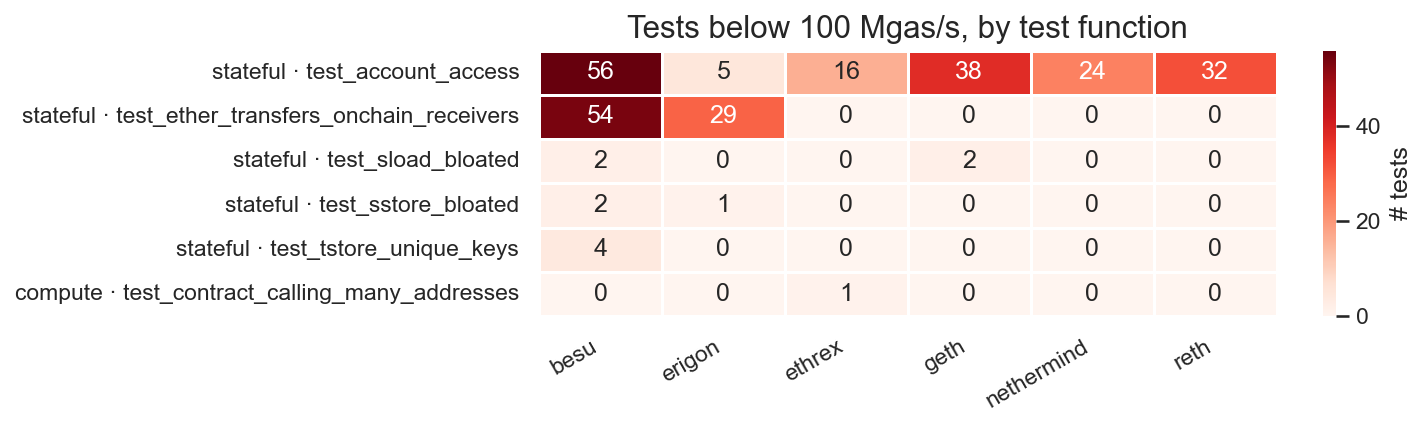

In [15]:
def plot_func_heatmap(flag: str, threshold: int) -> None:
    """Heatmap of tests below `threshold` per (suite, test function) and client."""
    pivot = by_test_df.pivot_table(
        index=["suite", "test_func"], columns="client", values=flag, aggfunc="sum"
    ).reindex(columns=CLIENT_ORDER)
    pivot = pivot[pivot.sum(axis=1) > 0].reindex(SUITE_ORDER, level="suite")
    if pivot.empty:
        print(f"No tests below {threshold} Mgas/s")
        return
    labels = [f"{suite} · {func}" for suite, func in pivot.index]

    fig, ax = plt.subplots(figsize=(10, max(2.2, 0.5 * len(pivot))))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".0f",
        cmap="Reds",
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "# tests"},
        ax=ax,
    )
    ax.set_yticklabels(labels, rotation=0)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
    ax.set_title(f"Tests below {threshold} Mgas/s, by test function")
    ax.set_ylabel("")
    ax.set_xlabel("")
    plt.tight_layout()
    plt.show()


plot_func_heatmap("below_anchor", ANCHOR_MGAS_S)

In [16]:
plot_func_heatmap("below_soft", SOFT_MGAS_S)

No tests below 50 Mgas/s


In [17]:
below_soft_df = by_test_df[by_test_df["below_soft"]].sort_values("median_mgas_s")
display(
    below_soft_df[
        [
            "suite",
            "client",
            "test_func",
            "test_params",
            "median_mgas_s",
            "min_mgas_s",
            "median_time_s",
            "n_runs",
        ]
    ]
    .assign(
        test_params=lambda d: d["test_params"].str.replace(
            "fork_Amsterdam-blockchain_test_stateful_engine-", "", regex=False
        ),
        median_mgas_s=lambda d: d["median_mgas_s"].round(1),
        min_mgas_s=lambda d: d["min_mgas_s"].round(1),
        median_time_s=lambda d: d["median_time_s"].round(2),
    )
    .reset_index(drop=True)
)

,suite,client,test_func,test_params,median_mgas_s,min_mgas_s,median_time_s,n_runs


**Two functions account for almost every stateful miss.** `test_account_access` affects all six clients (171 tests in total), and `test_ether_transfers_onchain_receivers` adds 54 for besu and 29 for erigon. The remainder is a handful of `test_sload_bloated`, `test_sstore_bloated`, and `test_tstore_unique_keys` cases. The only compute miss is one ethrex `test_contract_calling_many_addresses` case at 96.7 Mgas/s.

The slowest cases share a shape: the largest code size (65,536 bytes) combined with cold access (`NO_CACHE`, or a transfer to a distinct contract). The data alone do not identify the cause or separate implementation, build, and configuration effects.

Because no test falls below 50 Mgas/s, the second heatmap and the table below are empty.

## 5. Tests targeting 200M gas: which have median time above six seconds?

`target_gas_m` is parsed from the test name, and actual gas used can be substantially lower — so we compare **measured median execution time** against the six-second budget and report the actual gas range. At exactly 200M gas, six seconds corresponds to 33.3 Mgas/s, a less demanding requirement than 50 Mgas/s.

In [18]:
gas_200m_df = by_test_df[by_test_df["target_gas_m"] == 200].copy()
gas_200m_df["over_budget"] = gas_200m_df["median_time_s"] > TIME_BUDGET_S
budget_summary = (
    gas_200m_df.groupby(["suite", "client"])
    .agg(
        observed_tests=("test_name", "size"),
        n_over_budget=("over_budget", "sum"),
        slowest_median_s=("median_time_s", "max"),
        median_s=("median_time_s", "median"),
        min_actual_gas=("min_gas_used", "min"),
        max_actual_gas=("max_gas_used", "max"),
    )
    .reindex(comparison_index)
)
display(budget_summary.round(2))

observed_tests  n_over_budget  slowest_median_s  \
suite    client                                                        
stateful besu                   266              0              3.27   
         erigon                 266              0              3.72   
         ethrex                 266              0              2.77   
         geth                   266              0              3.15   
         nethermind             266              0              2.67   
         reth                   266              0              3.17   
compute  besu                  1150              0              1.17   
         erigon                1150              0              1.01   
         ethrex                1150              0              2.07   
         geth                  1150              0              1.55   
         nethermind            1150              0              0.87   
         reth                  1150              0              0.86   

                     median_s  min_actual_gas  max_actual_gas  
suite    client                                                
stateful besu            1.42       168030238       200093445  
         erigon          0.34       168030238       200093445  
         ethrex          0.21       168030238       200093445  
         geth            0.45       168030238       200093445  
         nethermind      0.35       168030238       200093445  
         reth            0.36       168030238       200093445  
compute  besu            0.25       100453680       200000000  
         erigon          0.09       100453680       200000000  
         ethrex          0.06       100453680       200000000  
         geth            0.09       100453680       200000000  
         nethermind      0.04       100453680       200000000  
         reth            0.05       100453680       200000000

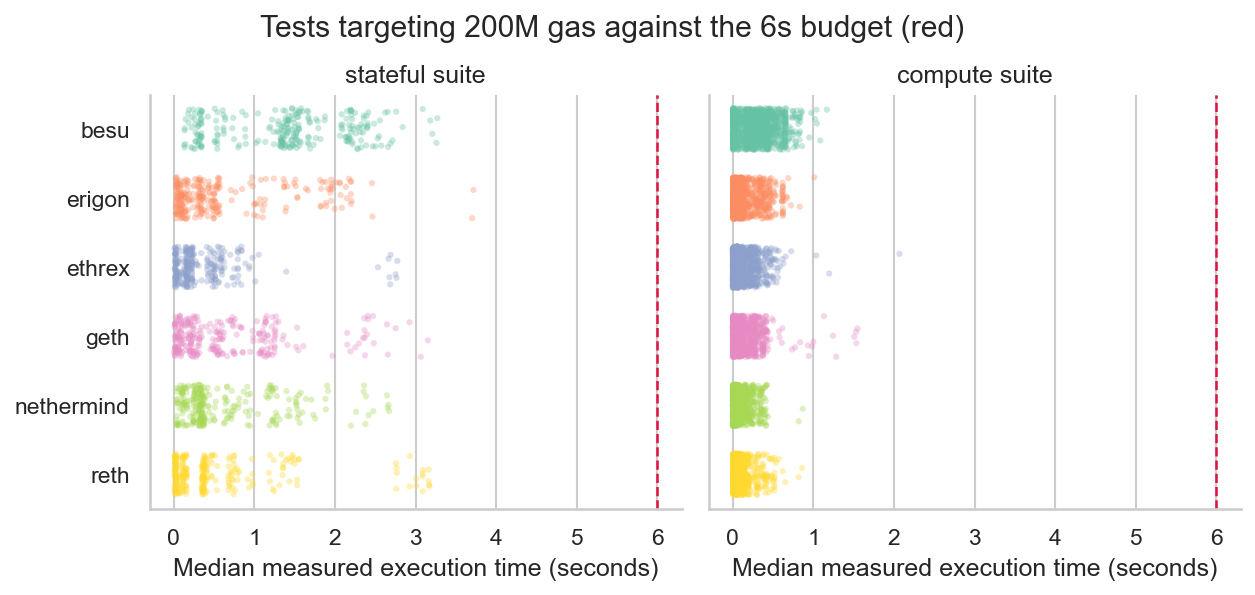

In [19]:
g = sns.catplot(
    data=gas_200m_df,
    y="client",
    x="median_time_s",
    hue="client",
    hue_order=CLIENT_ORDER,
    order=CLIENT_ORDER,
    col="suite",
    col_order=SUITE_ORDER,
    kind="strip",
    alpha=0.35,
    size=3,
    jitter=0.3,
    legend=False,
    height=3.8,
    aspect=1.15,
)
for ax in g.axes.flat:
    ax.axvline(TIME_BUDGET_S, color="crimson", linestyle="--", linewidth=1.2)
g.set_titles("{col_name} suite")
g.set_xlabels("Median measured execution time (seconds)")
g.set_ylabels("")
g.figure.suptitle(
    f"Tests targeting 200M gas against the {TIME_BUDGET_S}s budget (red)", y=1.04
)
plt.show()

In [20]:
over_budget_df = gas_200m_df[gas_200m_df["over_budget"]].sort_values(
    "median_time_s", ascending=False
)
print(
    f"{len(over_budget_df)} (suite, client, test) pairs have median time above {TIME_BUDGET_S}s"
)

display(
    over_budget_df[
        [
            "suite",
            "client",
            "test_func",
            "test_params",
            "median_time_s",
            "median_mgas_s",
            "n_runs",
            "min_gas_used",
            "max_gas_used",
        ]
    ]
    .assign(
        test_params=lambda d: d["test_params"].str.replace(
            "fork_Amsterdam-blockchain_test_stateful_engine-", "", regex=False
        ),
        median_time_s=lambda d: d["median_time_s"].round(2),
        median_mgas_s=lambda d: d["median_mgas_s"].round(1),
    )
    .reset_index(drop=True)
)

0 (suite, client, test) pairs have median time above 6s


,suite,client,test_func,test_params,median_time_s,median_mgas_s,n_runs,min_gas_used,max_gas_used


In [21]:
display(
    over_budget_df.pivot_table(
        index=["suite", "test_func"],
        columns="client",
        values="median_time_s",
        aggfunc="max",
    )
    .reindex(columns=CLIENT_ORDER)
    .round(2)
)

,client,besu,erigon,ethrex,geth,nethermind,reth
suite,test_func,,,,,,


**No test targeting 200M gas exceeds the six-second budget.** The slowest median is 3.7s (erigon, `test_ether_transfers_onchain_receivers`); the other clients top out between 2.7s and 3.3s, all on stateful tests. Headroom in that tail is under a factor of two.

Two limits on reading this. These are medians, not the slowest recorded execution. And actual gas used spans 168M–200M in the stateful suite and 100M–200M in compute, so this is not a measurement of exactly-200M blocks.

## Summary

The tables below are generated from the filtered data, so dates, counts, coverage, and repetition ranges stay aligned when the notebook is rerun.

- **Coverage is complete.** All six clients have completed, fully passing runs for both suites; only two compute tests lack a positive timing.
- **No test median falls below 50 Mgas/s**, and no test targeting 200M gas exceeds the six-second budget. The slowest median throughput anywhere is 53.8 Mgas/s.
- **Misses against the 100 Mgas/s anchor are stateful and client-specific:** besu 118 of 532 (22%), geth 40, erigon 35, reth 32, nethermind 24, ethrex 16. Compute has one miss in total.
- **`test_account_access` is the common factor**, affecting every client. `test_ether_transfers_onchain_receivers` adds to besu and erigon only.

Stateful account access and on-chain receiver transfers are where further investigation is worthwhile. These are descriptive statistics for one build and hardware mix: they do not establish a cause, a repricing factor, or performance at a different block size.

In [22]:
display(
    Markdown(
        f"**Run-start window:** [{WINDOW_START}, {AS_OF}). "
        f"**Measurements:** {len(raw_df):,} inside the window; {len(df):,} after the Besu instance filter. "
        f"**Budget:** {len(over_budget_df)} observed test/client pairs targeting 200M gas "
        f"have median measured time above {TIME_BUDGET_S} seconds."
    )
)
summary_table = threshold_summary.set_index(["suite", "client"])[
    [
        "observed_tests",
        "expected_tests",
        "unobserved_tests",
        "n_below_anchor",
        "pct_below_anchor",
        "n_below_soft",
        "pct_below_soft",
        "slowest_mgas_s",
        "median_mgas_s",
        "min_runs_per_test",
        "max_runs_per_test",
    ]
]
display(
    summary_table.rename(
        columns={
            "n_below_anchor": f"median < {ANCHOR_MGAS_S} Mgas/s",
            "n_below_soft": f"median < {SOFT_MGAS_S} Mgas/s",
            "slowest_mgas_s": "slowest test median (Mgas/s)",
            "median_mgas_s": "median across tests (Mgas/s)",
        }
    ).round(1)
)

**Run-start window:** [2026-09-10 00:00:00+00:00, 2026-09-14 00:00:00+00:00). **Measurements:** 1,907,252 inside the window; 1,907,252 after the Besu instance filter. **Budget:** 0 observed test/client pairs targeting 200M gas have median measured time above 6 seconds.

observed_tests  expected_tests  unobserved_tests  \
suite    client                                                         
stateful besu                   532             532                 0   
         erigon                 532             532                 0   
         ethrex                 532             532                 0   
         geth                   532             532                 0   
         nethermind             532             532                 0   
         reth                   532             532                 0   
compute  besu                  2300            2302                 2   
         erigon                2300            2302                 2   
         ethrex                2300            2302                 2   
         geth                  2300            2302                 2   
         nethermind            2300            2302                 2   
         reth                  2300            2302                 2   

                     median < 100 Mgas/s  pct_below_anchor  \
suite    client                                              
stateful besu                        118              22.2   
         erigon                       35               6.6   
         ethrex                       16               3.0   
         geth                         40               7.5   
         nethermind                   24               4.5   
         reth                         32               6.0   
compute  besu                          0               0.0   
         erigon                        0               0.0   
         ethrex                        1               0.0   
         geth                          0               0.0   
         nethermind                    0               0.0   
         reth                          0               0.0   

                     median < 50 Mgas/s  pct_below_soft  \
suite    client                                           
stateful besu                         0             0.0   
         erigon                       0             0.0   
         ethrex                       0             0.0   
         geth                         0             0.0   
         nethermind                   0             0.0   
         reth                         0             0.0   
compute  besu                         0             0.0   
         erigon                       0             0.0   
         ethrex                       0             0.0   
         geth                         0             0.0   
         nethermind                   0             0.0   
         reth                         0             0.0   

                     slowest test median (Mgas/s)  \
suite    client                                     
stateful besu                                61.2   
         erigon                              53.8   
         ethrex                              72.1   
         geth                                63.5   
         nethermind                          74.9   
         reth                                63.1   
compute  besu                               171.5   
         erigon                             197.6   
         ethrex                              96.7   
         geth                               129.3   
         nethermind                         230.3   
         reth                               232.3   

                     median across tests (Mgas/s)  min_runs_per_test  \
suite    client                                                        
stateful besu                               149.1                 18   
         erigon                             588.8                 14   
         ethrex                             983.6                 16   
         geth                               389.7                428   
         nethermind                         610.9                 16   
         reth                               601.6      